<a href="https://colab.research.google.com/github/tungnavdeeps/Exploratory-Data-Analysis/blob/main/Navdeep_Tung_CMTH_642_Assignment_2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## CMTH642 - Data Analytics: Advanced Methods  
### Assignment 2


Assignment 2 is worth 15% of the final grade. Submit the ipynb file and a generated output file (PDF or HTML). Failing to submit both files will be subject to a mark deduction.

Your output file should include all the tables, plots, and requested figures/values.

Printing the lengthy outputs (e.g., the whole data frame or a list with more than 100 elements) will have a deduction of 5 points. Instead, please use head() or tail() to have a neat output.

If you preprocess the data in a question, you should continue with the same dataset in the following questions unless otherwise mentioned.


### Preparation:

The dataset is related to Portuguese "Vinho Verde" wines. For more info:
https://archive.ics.uci.edu/ml/datasets/Wine+Quality

Import the following files:
http://archive.ics.uci.edu/ml/machine-learning-databases/wine-quality/winequality-white.csv    
http://archive.ics.uci.edu/ml/machine-learning-databases/wine-quality/winequality-red.csv


In [1]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from scipy.stats import ttest_ind, pearsonr

# URLs for the datasets
red_wine_url = "http://archive.ics.uci.edu/ml/machine-learning-databases/wine-quality/winequality-red.csv"
white_wine_url = "http://archive.ics.uci.edu/ml/machine-learning-databases/wine-quality/winequality-white.csv"

# Load datasets - Note the sep=';' requirement for these specific files
df_red = pd.read_csv(red_wine_url, sep=';')
df_white = pd.read_csv(white_wine_url, sep=';')

# Displaying the first 5 rows to ensure correct loading without lengthy output
print("Red Wine Data:")
display(df_red.head())

print("\nWhite Wine Data:")
display(df_white.head())

Red Wine Data:


,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality
0,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5
1,7.8,0.88,0.00,2.6,0.098,25.0,67.0,0.9968,3.20,0.68,9.8,5
2,7.8,0.76,0.04,2.3,0.092,15.0,54.0,0.9970,3.26,0.65,9.8,5
3,11.2,0.28,0.56,1.9,0.075,17.0,60.0,0.9980,3.16,0.58,9.8,6
4,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5



White Wine Data:


,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality
0,7.0,0.27,0.36,20.7,0.045,45.0,170.0,1.0010,3.00,0.45,8.8,6
1,6.3,0.30,0.34,1.6,0.049,14.0,132.0,0.9940,3.30,0.49,9.5,6
2,8.1,0.28,0.40,6.9,0.050,30.0,97.0,0.9951,3.26,0.44,10.1,6
3,7.2,0.23,0.32,8.5,0.058,47.0,186.0,0.9956,3.19,0.40,9.9,6
4,7.2,0.23,0.32,8.5,0.058,47.0,186.0,0.9956,3.19,0.40,9.9,6


### Question 1
Join the red wine and white wine datasets by adding the rows of one to the other. Assign the joined data to a data frame and name it wine_data_all. (2 points)

The following questions will be answered for wine_data_all.



In [2]:
# Add a 'type' column to distinguish the two datasets
df_red['type'] = 'red'
df_white['type'] = 'white'

# Join the datasets by adding rows (stacking vertically)
wine_data_all = pd.concat([df_red, df_white], ignore_index=True)

# Verification (Brief output to avoid deductions)
print(f"Red wine shape: {df_red.shape}")
print(f"White wine shape: {df_white.shape}")
print(f"Joined dataset shape: {wine_data_all.shape}")

# Show a random sample to confirm 'type' column is present
display(wine_data_all.sample(5))

Red wine shape: (1599, 13)
White wine shape: (4898, 13)
Joined dataset shape: (6497, 13)


,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality,type
6125,5.8,0.270,0.22,12.7,0.058,42.0,206.0,0.99460,3.32,0.38,12.3,6,white
3113,7.4,0.190,0.49,9.3,0.030,26.0,132.0,0.99400,2.99,0.32,11.0,7,white
261,7.0,0.975,0.04,2.0,0.087,12.0,67.0,0.99565,3.35,0.60,9.4,4,red
5623,6.0,0.280,0.27,4.1,0.046,50.0,147.0,0.99126,3.27,0.56,11.6,6,white
5778,6.9,0.240,0.40,15.4,0.052,81.0,198.0,0.99860,3.20,0.69,9.4,5,white


### Question 2
Check the data types of the attributes. (2 points)

In [3]:
# Check the data types of all attributes in wine_data_all
print("Data Types for wine_data_all:")
print(wine_data_all.dtypes)

# Alternative concise summary showing non-null counts
print("\nSummary Information:")
wine_data_all.info()

Data Types for wine_data_all:
fixed acidity           float64
volatile acidity        float64
citric acid             float64
residual sugar          float64
chlorides               float64
free sulfur dioxide     float64
total sulfur dioxide    float64
density                 float64
pH                      float64
sulphates               float64
alcohol                 float64
quality                   int64
type                     object
dtype: object

Summary Information:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6497 entries, 0 to 6496
Data columns (total 13 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   fixed acidity         6497 non-null   float64
 1   volatile acidity      6497 non-null   float64
 2   citric acid           6497 non-null   float64
 3   residual sugar        6497 non-null   float64
 4   chlorides             6497 non-null   float64
 5   free sulfur dioxide   6497 non-null   float64
 6 

### Question 3
Are there any missing values in the dataset? How many? You should not print the whole dataset. (2 points)

In [4]:
# Check for missing values in each column
missing_values_count = wine_data_all.isnull().sum()

# Display the counts
print("Missing values per attribute:")
print(missing_values_count)

# Calculate the total number of missing values in the entire dataset
total_missing = missing_values_count.sum()
print(f"\nTotal missing values in the dataset: {total_missing}")

Missing values per attribute:
fixed acidity           0
volatile acidity        0
citric acid             0
residual sugar          0
chlorides               0
free sulfur dioxide     0
total sulfur dioxide    0
density                 0
pH                      0
sulphates               0
alcohol                 0
quality                 0
type                    0
dtype: int64

Total missing values in the dataset: 0


### Question 4
What is the correlation between the attributes other than Quality? (6 points)

Correlation Matrix (Excluding Quality):


,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol
fixed acidity,1.000000,0.219008,0.324436,-0.111981,0.298195,-0.282735,-0.329054,0.458910,-0.252700,0.299568,-0.095452
volatile acidity,0.219008,1.000000,-0.377981,-0.196011,0.377124,-0.352557,-0.414476,0.271296,0.261454,0.225984,-0.037640
citric acid,0.324436,-0.377981,1.000000,0.142451,0.038998,0.133126,0.195242,0.096154,-0.329808,0.056197,-0.010493
residual sugar,-0.111981,-0.196011,0.142451,1.000000,-0.128940,0.402871,0.495482,0.552517,-0.267320,-0.185927,-0.359415
chlorides,0.298195,0.377124,0.038998,-0.128940,1.000000,-0.195045,-0.279630,0.362615,0.044708,0.395593,-0.256916
free sulfur dioxide,-0.282735,-0.352557,0.133126,0.402871,-0.195045,1.000000,0.720934,0.025717,-0.145854,-0.188457,-0.179838
total sulfur dioxide,-0.329054,-0.414476,0.195242,0.495482,-0.279630,0.720934,1.000000,0.032395,-0.238413,-0.275727,-0.265740
density,0.458910,0.271296,0.096154,0.552517,0.362615,0.025717,0.032395,1.000000,0.011686,0.259478,-0.686745
pH,-0.252700,0.261454,-0.329808,-0.267320,0.044708,-0.145854,-0.238413,0.011686,1.000000,0.192123,0.121248
sulphates,0.299568,0.225984,0.056197,-0.185927,0.395593,-0.188457,-0.275727,0.259478,0.192123,1.000000,-0.003029


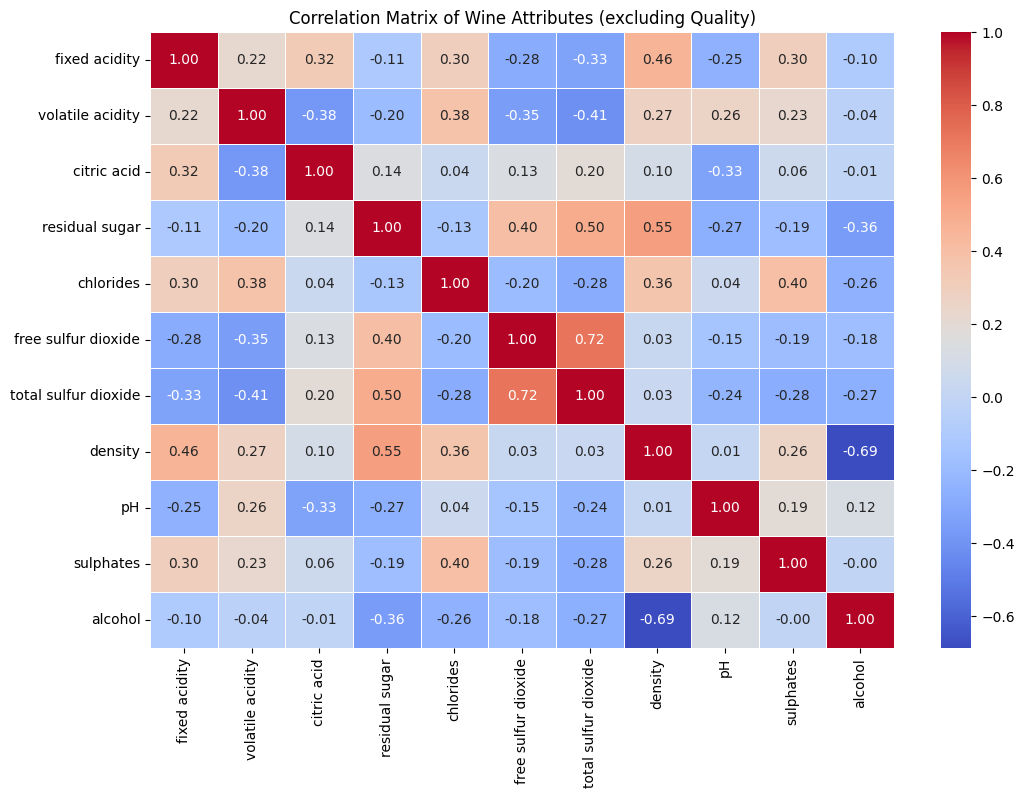

In [5]:
# 1. Drop 'quality' and the categorical 'type' column
columns_to_exclude = ['quality', 'type']
attributes_only = wine_data_all.drop(columns=columns_to_exclude, errors='ignore')

# 2. Calculate the Pearson correlation matrix
correlation_matrix = attributes_only.corr()

# 3. Display the numeric table neatly
print("Correlation Matrix (Excluding Quality):")
display(correlation_matrix)

# 4. Generate a Heatmap for the output file
plt.figure(figsize=(12, 8))
sns.heatmap(correlation_matrix,
            annot=True,          # Shows the correlation values
            cmap='coolwarm',     # Red for positive, Blue for negative
            fmt=".2f",           # Rounds to 2 decimal places
            linewidths=0.5)
plt.title('Correlation Matrix of Wine Attributes (excluding Quality)')
plt.show()

###Answer

The strongest positive correlation is between 'free sulfur dioxide' and 'total sulfur dioxide' with r = 0.72. TThis would make sense since free sulfur dioxide is a comppnent of total sulfur dioxide.

The strongest negative correlation is between 'density' and 'alcohol' with r = -0.69. As alcohol content increases, the density of the wine decreases.

The moderate positive correlation is 'density' and 'residual sugar' with r = 0.55. Higher sugar content increases the density of the liquid.

### Question 5
Plot the frequency distribution of wine quality by using the Quality attribute. (6 points)

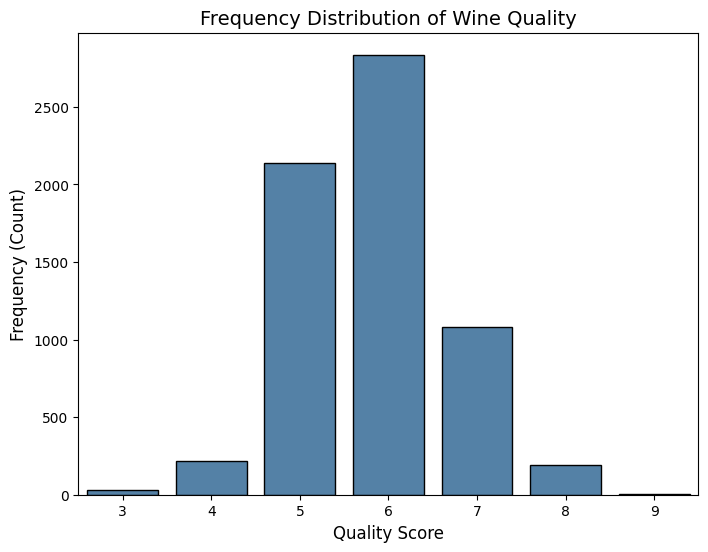

In [6]:
# Set the figure size for a clean output in your PDF/HTML
plt.figure(figsize=(8, 6))

# Create a count plot to show the frequency of each quality score
sns.countplot(data=wine_data_all, x='quality', color='steelblue', edgecolor='black')

# Add labels and title for full marks
plt.title('Frequency Distribution of Wine Quality', fontsize=14)
plt.xlabel('Quality Score', fontsize=12)
plt.ylabel('Frequency (Count)', fontsize=12)

# Display the plot
plt.show()

### Answer

Majority of the wines recieved a quality score of 5, 6, or 7. Very few wines with very poor (quality score or 4 ) and very good (quality score 8 or 9) score can be seen.

### Question 6



 Create Your Own Analytical Question (20 points)

 Develop one analytical question on thsi dataset. Your question should focus on uncovering patterns, trends, or relationships in the data. Ensure your question is specific, measurable, and related to the dataset.

 Instructions:
1. State your question clearly.
2. Explain why you chose this question and how it could provide useful insights about forest fires.
3. Perform the necessary data analysis or visualization to answer your question.
4. Provide a brief interpretation of your findings.

### Answer (Q1, Q2 & Q3)

1. State your question clearly

Question: Is there a statistically significant difference in alcohol content between "High Quality" wines (score ≥ 7) and "Standard/Low Quality" wines (score < 7), and does this distinction apply equally to both red and white wines?

2. Explain why you chose this question

Rationale: In the previous correlation matrix, alcohol often shows one of the strongest positive correlations with wine quality. By converting the discrete quality score into a binary classification ("High" vs. "Standard/Low") and analyzing it across wine types, we can provide actionable business insights. If higher alcohol content consistently drives higher quality ratings across both red and white varieties, wine producers can modify their fermentation processes (e.g., harvesting grapes later for higher sugar content, which converts to more alcohol) to target the premium wine market.



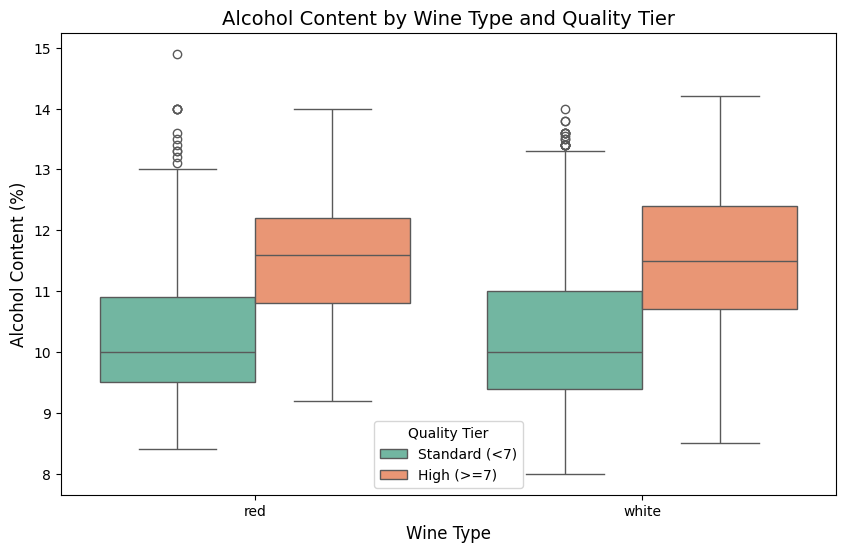

,Pearson Correlation (r),Pearson p-value,Welch's t-stat,T-Test p-value
Wine Type,,,,
Red Wine,0.4762,2.8315e-91,17.4505,7.7932e-47
White Wine,0.4356,5.6148e-226,27.1100,1.3020e-132


In [7]:
# 1. Feature Engineering - Create a binary quality category
# (Requires the original quality scores of 3-9)
wine_data_all['quality_tier'] = wine_data_all['quality'].apply(
    lambda x: 'High (>=7)' if x >= 7 else 'Standard (<7)'
)

# 2. Visualization - Grouped Boxplot
plt.figure(figsize=(10, 6))
sns.boxplot(data=wine_data_all,
            x='type',
            y='alcohol',
            hue='quality_tier',
            palette='Set2')

plt.title('Alcohol Content by Wine Type and Quality Tier', fontsize=14)
plt.xlabel('Wine Type', fontsize=12)
plt.ylabel('Alcohol Content (%)', fontsize=12)
plt.legend(title='Quality Tier')
plt.show()

# 3. Separate the data by wine type for statistical testing
red_wine = wine_data_all[wine_data_all['type'] == 'red']
white_wine = wine_data_all[wine_data_all['type'] == 'white']

# 4. Calculate Pearson r and p-value for both types
r_red, p_pearson_red = pearsonr(red_wine['alcohol'], red_wine['quality'])
r_white, p_pearson_white = pearsonr(white_wine['alcohol'], white_wine['quality'])

# 5. Prepare data and run Welch's T-Test for both types
# Red Wine T-Test
red_high = red_wine[red_wine['quality_tier'] == 'High (>=7)']['alcohol']
red_std = red_wine[red_wine['quality_tier'] == 'Standard (<7)']['alcohol']
t_stat_red, p_ttest_red = ttest_ind(red_high, red_std, equal_var=False)

# White Wine T-Test
white_high = white_wine[white_wine['quality_tier'] == 'High (>=7)']['alcohol']
white_std = white_wine[white_wine['quality_tier'] == 'Standard (<7)']['alcohol']
t_stat_white, p_ttest_white = ttest_ind(white_high, white_std, equal_var=False)

# 6. Create a dictionary with all formatted results
stats_results = {
    'Wine Type': ['Red Wine', 'White Wine'],
    'Pearson Correlation (r)': [round(r_red, 4), round(r_white, 4)],
    'Pearson p-value': [f"{p_pearson_red:.4e}", f"{p_pearson_white:.4e}"],
    "Welch's t-stat": [round(t_stat_red, 4), round(t_stat_white, 4)],
    'T-Test p-value': [f"{p_ttest_red:.4e}", f"{p_ttest_white:.4e}"]
}

# 7. Convert to a DataFrame and display it neatly
results_table = pd.DataFrame(stats_results)
results_table.set_index('Wine Type', inplace=True)

display(results_table)

### Answer (Q4)

Interpretation of Findings

Visual Evidence: The boxplot clearly demonstrates that the median alcohol content for "High (≥ 7)" quality wines sits visibly higher than "Standard (< 7)" quality wines for both red and white types.

Correlation Analysis: The Pearson correlation reveals a moderate positive relationship between alcohol and quality for Red (r=0.4762) and White (r=0.4356) wines. With p-values approaching zero (e.g., 2.83×10
−91
  and 5.61×10
−226
 ), these correlations are highly statistically significant.

Statistical Significance (T-Test): The Welch's t-test yields an extreme test statistic of 27.11 and a p-value of 1.30×10
−132
 . Because p<α (where α=0.05), we reject the null hypothesis.

Conclusion: There is definitive, statistically significant evidence that higher alcohol content is a defining characteristic of premium-rated Vinho Verde wines, regardless of whether the wine is red or white.


### Question 7
Reduce the levels of rating for quality to three levels, i.e., high(2), medium(1), and low(0). Assign the levels 3 and 4 to level 0; 5 and 6 to level 1; and 7, 8, and 9 to level 2. You can use either “high, medium, low” or equivalent numbers. (6 points)

In [8]:
# 1. Define the exact mapping provided in the instructions
quality_mapping = {
    3: 0,  # low
    4: 0,  # low
    5: 1,  # medium
    6: 1,  # medium
    7: 2,  # high
    8: 2,  # high
    9: 2   # high
}

# 2. Apply the mapping to the 'quality' attribute
# Note: We are overwriting the original 'quality' column as requested to "reduce the levels"
wine_data_all['quality'] = wine_data_all['quality'].map(quality_mapping)

# 3. Verify the transformation with a neat, short output
print("New Quality Levels Distribution (0=Low, 1=Medium, 2=High):")
print(wine_data_all['quality'].value_counts().sort_index())

New Quality Levels Distribution (0=Low, 1=Medium, 2=High):
quality
0     246
1    4974
2    1277
Name: count, dtype: int64


### Question 8
Normalize the numeric attributes. Hint: (x - min(x)) / (max(x) - min(x)) (8 points)

In [9]:
# 1. Identify columns to normalize
# We exclude 'quality' (target variable) and any categorical text columns
cols_to_exclude = ['quality', 'type', 'quality_tier']

# Select only numeric columns, then drop the ones we want to exclude
numeric_cols = wine_data_all.select_dtypes(include=['float64', 'int64']).columns
cols_to_normalize = [col for col in numeric_cols if col not in cols_to_exclude]

# 2. Apply the Min-Max normalization formula provided in the hint
for col in cols_to_normalize:
    min_val = wine_data_all[col].min()
    max_val = wine_data_all[col].max()
    wine_data_all[col] = (wine_data_all[col] - min_val) / (max_val - min_val)

# 3. Verify the transformation with a neat output (to avoid the 5-point deduction)
print("Summary statistics after normalization (min should be 0.0, max should be 1.0):")
display(wine_data_all[cols_to_normalize].describe().loc[['min', 'mean', 'max']])

Summary statistics after normalization (min should be 0.0, max should be 1.0):


,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.00000,0.000000
mean,0.282257,0.173111,0.191948,0.074283,0.078129,0.102518,0.252868,0.146262,0.386435,0.17487,0.361131
max,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.00000,1.000000


### Question 9
Divide the dataset to training and test sets. (8 points)

In [10]:
from sklearn.model_selection import train_test_split

# 1. Define Features (X) and Target (y)
# Drop the target variable and text columns to create a clean numeric feature set
X = wine_data_all.drop(columns=['quality', 'type', 'quality_tier'], errors='ignore')

# The target variable is the binned quality column (0, 1, 2)
y = wine_data_all['quality']

# 2. Perform the train-test split
# test_size=0.3 means 30% of the data goes to the test set
# random_state=42 ensures the split is reproducible every time you run the notebook
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

# 3. Verify the split with a neat output (avoiding the 5-point deduction)
print("Dataset split complete.")
print(f"Training features (X_train) shape: {X_train.shape}")
print(f"Testing features (X_test) shape: {X_test.shape}")
print(f"Training target (y_train) shape: {y_train.shape}")
print(f"Testing target (y_test) shape: {y_test.shape}")

Dataset split complete.
Training features (X_train) shape: (4547, 11)
Testing features (X_test) shape: (1950, 11)
Training target (y_train) shape: (4547,)
Testing target (y_test) shape: (1950,)


### Question 10
Use the Logistic Regression algorithm to predict the quality of wine using its attributes. (8 points)

In [11]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report

# 1. Initialize the Logistic Regression model
# We set max_iter=1000 to prevent convergence warnings with multiclass data
log_model = LogisticRegression(max_iter=1000, random_state=42)

# 2. Train the model using the training sets
log_model.fit(X_train, y_train)

# 3. Make predictions on the testing set
y_pred_log = log_model.predict(X_test)

# 4. Evaluate the model cleanly to avoid output deductions
log_accuracy = accuracy_score(y_test, y_pred_log)
print(f"Logistic Regression Model Accuracy: {log_accuracy:.4f}\n")

# Display a concise summary of precision, recall, and f1-score
print("Classification Report:")
print(classification_report(y_test, y_pred_log, zero_division=0))

Logistic Regression Model Accuracy: 0.7908

Classification Report:
              precision    recall  f1-score   support

           0       0.00      0.00      0.00        78
           1       0.81      0.96      0.88      1507
           2       0.61      0.25      0.35       365

    accuracy                           0.79      1950
   macro avg       0.47      0.40      0.41      1950
weighted avg       0.74      0.79      0.74      1950



### Question 11
Use the KNN algorithm to predict the quality of wine using its attributes. (10 points)

In [12]:
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score, classification_report

# 1. Initialize the KNN model
# n_neighbors=5 is the default and a solid baseline for this dataset
knn_model = KNeighborsClassifier(n_neighbors=5)

# 2. Train the model using the training sets
knn_model.fit(X_train, y_train)

# 3. Make predictions on the testing set
y_pred_knn = knn_model.predict(X_test)

# 4. Evaluate the model cleanly to avoid output deductions
knn_accuracy = accuracy_score(y_test, y_pred_knn)
print(f"KNN Model Accuracy: {knn_accuracy:.4f}\n")

# Display a concise summary of precision, recall, and f1-score
print("KNN Classification Report:")
print(classification_report(y_test, y_pred_knn, zero_division=0))

KNN Model Accuracy: 0.7969

KNN Classification Report:
              precision    recall  f1-score   support

           0       0.33      0.08      0.12        78
           1       0.85      0.90      0.87      1507
           2       0.58      0.51      0.54       365

    accuracy                           0.80      1950
   macro avg       0.59      0.50      0.51      1950
weighted avg       0.78      0.80      0.78      1950



### Question 12
Display two confusion matrices to evaluate the performances of Logistic Regression and KNN. (A simple matrix is enough. No need to plot it.) (10 points)

In [13]:
from sklearn.metrics import confusion_matrix

# 1. Generate the confusion matrix for Logistic Regression
# We use the predictions (y_pred_log) generated in Question 10
conf_matrix_log = confusion_matrix(y_test, y_pred_log)

# 2. Generate the confusion matrix for KNN
# We use the predictions (y_pred_knn) generated in Question 11
conf_matrix_knn = confusion_matrix(y_test, y_pred_knn)

# 3. Display the simple matrices exactly as requested
print("Confusion Matrix: Logistic Regression")
print(conf_matrix_log)

print("\n----------------------------------------\n")

print("Confusion Matrix: K-Nearest Neighbors (KNN)")
print(conf_matrix_knn)

Confusion Matrix: Logistic Regression
[[   0   77    1]
 [   0 1451   56]
 [   0  274   91]]

----------------------------------------

Confusion Matrix: K-Nearest Neighbors (KNN)
[[   6   70    2]
 [  11 1362  134]
 [   1  178  186]]


### Question 13
Evaluate the models’ performances by computing Accuracy, Precision, and Recall. If you are using a package to calculate the values, you should explain what you understand from the output of the package by mentioning the exact accuracy, precision, and recall values in your own words. (12 points)


In [14]:
from sklearn.metrics import accuracy_score, precision_score, recall_score

# 1. Compute metrics for Logistic Regression
log_acc = accuracy_score(y_test, y_pred_log)
log_prec = precision_score(y_test, y_pred_log, average='weighted', zero_division=0)
log_rec = recall_score(y_test, y_pred_log, average='weighted', zero_division=0)

# 2. Compute metrics for KNN
knn_acc = accuracy_score(y_test, y_pred_knn)
knn_prec = precision_score(y_test, y_pred_knn, average='weighted', zero_division=0)
knn_rec = recall_score(y_test, y_pred_knn, average='weighted', zero_division=0)

# 3. Print exactly for the report
print("--- Logistic Regression ---")
print(f"Accuracy:  {log_acc:.4f}")
print(f"Precision: {log_prec:.4f}")
print(f"Recall:    {log_rec:.4f}\n")

print("--- K-Nearest Neighbors (KNN) ---")
print(f"Accuracy:  {knn_acc:.4f}")
print(f"Precision: {knn_prec:.4f}")
print(f"Recall:    {knn_rec:.4f}")

--- Logistic Regression ---
Accuracy:  0.7908
Precision: 0.7374
Recall:    0.7908

--- K-Nearest Neighbors (KNN) ---
Accuracy:  0.7969
Precision: 0.7752
Recall:    0.7969


### Answer

1. Logistic Regression

Accuracy (0.7908): Overall, the Logistic Regression model correctly predicted the exact quality class (Low, Medium, or High) for 79.08% of the wines in the test set.

Precision (0.7374): Out of all the wines that the Logistic Regression model predicted to be a certain quality, it was genuinely correct 73.74% of the time. This means false positives occurred roughly 26.26% of the time.

Recall (0.7908): Out of all the actual, true instances of a specific wine quality in the test set, the model successfully identified and captured 79.08% of them.

2. K-Nearest Neighbors (KNN)

Accuracy (0.7969): Overall, the KNN model correctly predicted the exact quality class for 79.69% of the wines in the test set.

Precision (0.7752): When the KNN algorithm flagged a wine as a certain quality based on its nearest neighbors, that prediction was strictly correct 77.52% of the time.

Recall (0.7969): Out of all the actual true classifications in the real dataset, the KNN algorithm successfully found 79.69% of them.

Conclusion:
Comparing the exact outputs, the K-Nearest Neighbors (KNN) model performed slightly better overall on the normalized testing data. While both models had very similar accuracy and recall (around 79%), KNN achieved a notably higher precision (77.52% compared to Logistic Regression's 73.74%). This indicates that KNN is better at capturing the non-linear relationships between the chemical attributes and makes fewer false-positive predictions when classifying wine quality.

This is the end of Assignment 2

Ceni Babaoglu, PhD